<a href="https://colab.research.google.com/github/Innocent-I/Smart-Irrigation-ML/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/Soil Moisture, Air Temperature and humidity, and Water Motor onoff Monitor data.AmritpalKaur.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (3000, 4)


,Soil Moisture,Temperature,Air Humidity,Pump Data
0,683.802906,29.184908,71.789699,0
1,408.571567,33.707205,77.977391,1
2,659.092074,24.760311,60.776282,1
3,842.929764,32.738515,59.323543,0
4,414.199320,25.692744,66.624914,1


In [4]:
# Check dataset information
print("=== DATASET INFORMATION ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Number of duplicates:", df.duplicated().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe())

=== DATASET INFORMATION ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Soil Moisture  3000 non-null   float64
 1   Temperature    3000 non-null   float64
 2   Air Humidity   3000 non-null   float64
 3   Pump Data      3000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 93.9 KB

=== MISSING VALUES ===
Soil Moisture    0
Temperature      0
Air Humidity     0
Pump Data        0
dtype: int64

=== DUPLICATE ROWS ===
Number of duplicates: 0

=== DESCRIPTIVE STATISTICS ===


,Soil Moisture,Temperature,Air Humidity,Pump Data
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,662.419754,28.443043,59.387209,0.523000
std,187.936297,6.018565,12.428161,0.499554
min,314.511016,18.002132,38.000201,0.000000
25%,501.362575,23.320750,48.661993,0.000000
50%,666.578554,28.361854,58.975423,1.000000
75%,821.867423,33.595989,70.138397,1.000000
max,984.828010,38.992770,81.267407,1.000000


In [5]:
# Count pump ON and OFF observations
pump_counts = df["Pump Data"].value_counts().sort_index()

print("Pump OFF (0):", pump_counts[0])
print("Pump ON  (1):", pump_counts[1])

# Compare environmental conditions by pump status
comparison = df.groupby("Pump Data")[
    ["Soil Moisture", "Temperature", "Air Humidity"]
].mean()

print("\nAverage conditions by pump status:")
display(comparison)

Pump OFF (0): 1431
Pump ON  (1): 1569

Average conditions by pump status:


,Soil Moisture,Temperature,Air Humidity
Pump Data,,,
0,830.562181,28.412407,59.371580
1,509.066145,28.470985,59.401464


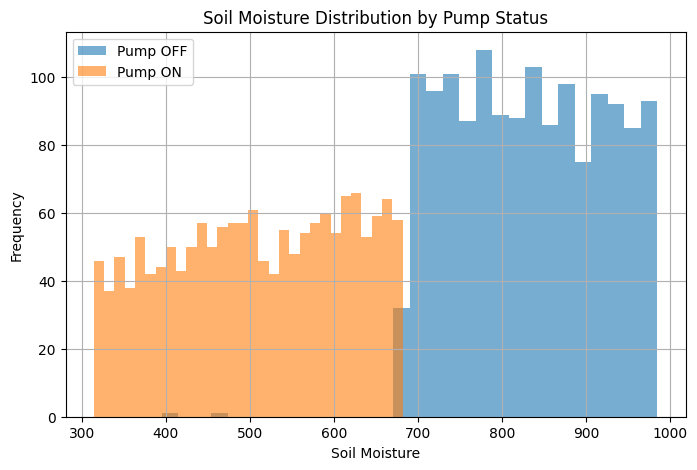

In [6]:
# Visualize soil moisture according to pump status
plt.figure(figsize=(8, 5))

df[df["Pump Data"] == 0]["Soil Moisture"].hist(
    bins=30, alpha=0.6, label="Pump OFF"
)

df[df["Pump Data"] == 1]["Soil Moisture"].hist(
    bins=30, alpha=0.6, label="Pump ON"
)

plt.xlabel("Soil Moisture")
plt.ylabel("Frequency")
plt.title("Soil Moisture Distribution by Pump Status")
plt.legend()
plt.show()

Correlation Matrix:


,Soil Moisture,Temperature,Air Humidity,Pump Data
Soil Moisture,1.000000,0.013642,-0.005748,-0.854569
Temperature,0.013642,1.000000,0.003129,0.004862
Air Humidity,-0.005748,0.003129,1.000000,0.001201
Pump Data,-0.854569,0.004862,0.001201,1.000000


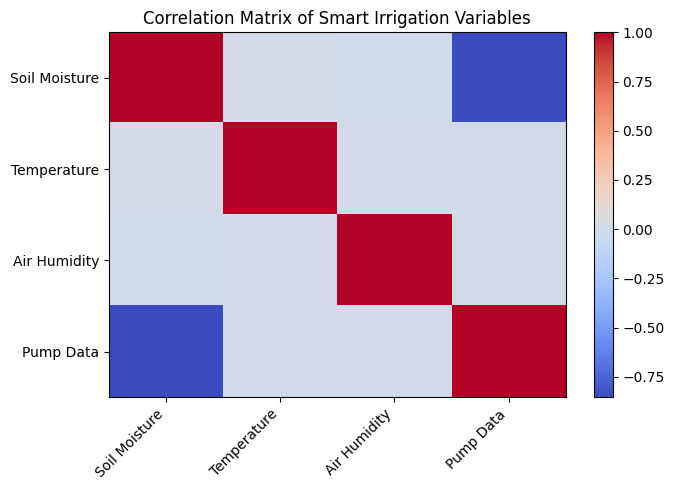

In [7]:
# Calculate correlations between variables
correlation = df.corr(numeric_only=True)

print("Correlation Matrix:")
display(correlation)

# Visualize correlation matrix
plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Smart Irrigation Variables")
plt.tight_layout()
plt.show()

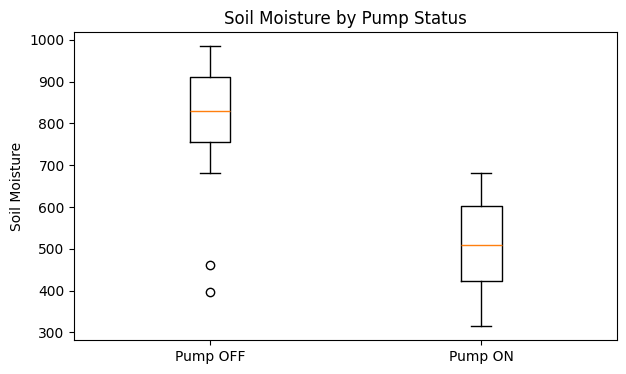

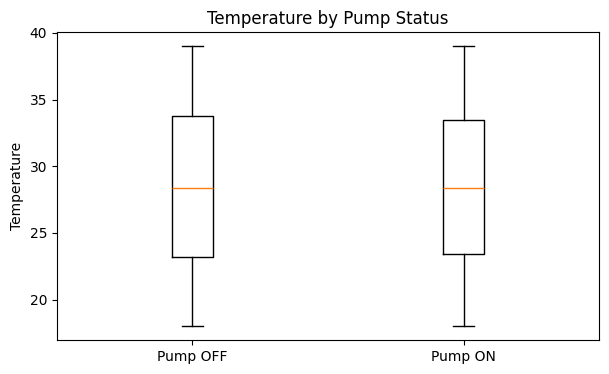

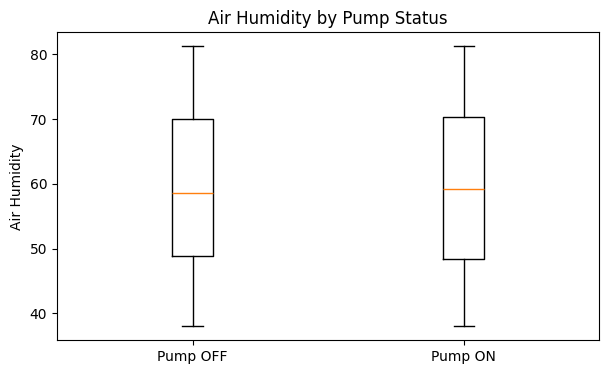

In [8]:
# Compare environmental variables by pump status

features = ["Soil Moisture", "Temperature", "Air Humidity"]

for feature in features:
    plt.figure(figsize=(7, 4))

    data_off = df[df["Pump Data"] == 0][feature]
    data_on = df[df["Pump Data"] == 1][feature]

    plt.boxplot(
        [data_off, data_on],
        tick_labels=["Pump OFF", "Pump ON"]
    )

    plt.ylabel(feature)
    plt.title(f"{feature} by Pump Status")
    plt.show()

In [9]:
## Key Findings

The exploratory data analysis produced the following observations:

1. The dataset contains 3,000 observations and four variables: Soil Moisture, Temperature, Air Humidity, and Pump Data.
2. No missing values or duplicate observations were identified.
3. The target variable is reasonably balanced, with 1,569 Pump ON observations and 1,431 Pump OFF observations.
4. Soil Moisture has a strong negative correlation with Pump Data (approximately -0.855).
5. Temperature and Air Humidity show almost no linear correlation with Pump Data in this dataset.
6. The average raw Soil Moisture reading is approximately 509 when the pump is ON and 831 when the pump is OFF.
7. These results suggest that the raw soil-moisture sensor measurement is the dominant predictor of pump status in this dataset.

### Next Step

The next stage will preprocess the data and establish a simple baseline before training machine learning classifiers. This will help determine whether machine learning provides predictive value beyond a simple soil-moisture threshold.

SyntaxError: invalid syntax (1650612981.py, line 3)

## Key Findings

The exploratory data analysis produced the following observations:

1. The dataset contains 3,000 observations and four variables: Soil Moisture, Temperature, Air Humidity, and Pump Data.
2. No missing values or duplicate observations were identified.
3. The target variable is reasonably balanced, with 1,569 Pump ON observations and 1,431 Pump OFF observations.
4. Soil Moisture has a strong negative correlation with Pump Data (approximately -0.855).
5. Temperature and Air Humidity show almost no linear correlation with Pump Data in this dataset.
6. The average raw Soil Moisture reading is approximately 509 when the pump is ON and 831 when the pump is OFF.
7. These results suggest that the raw soil-moisture sensor measurement is the dominant predictor of pump status in this dataset.

### Next Step

The next stage will preprocess the data and establish a simple baseline before training machine learning classifiers. This will help determine whether machine learning provides predictive value beyond a simple soil-moisture threshold.

## Key Findings

The exploratory data analysis produced the following observations:

1. The dataset contains 3,000 observations and four variables: Soil Moisture, Temperature, Air Humidity, and Pump Data.
2. No missing values or duplicate observations were identified.
3. The target variable is reasonably balanced, with 1,569 Pump ON observations and 1,431 Pump OFF observations.
4. Soil Moisture has a strong negative correlation with Pump Data (approximately -0.855).
5. Temperature and Air Humidity show almost no linear correlation with Pump Data.
6. The average raw Soil Moisture reading is approximately 509 when the pump is ON and 831 when the pump is OFF.
7. The boxplots confirm that Soil Moisture provides much stronger separation between pump states than Temperature or Air Humidity.
8. A small number of unusual Soil Moisture observations are present and will be investigated during preprocessing rather than automatically removed.

### Conclusion

The exploratory analysis suggests that the raw soil-moisture sensor reading is the dominant predictor of pump status in this dataset.

The next stage will preprocess the data and establish a simple soil-moisture baseline before training machine learning classifiers. This will allow us to determine whether machine learning provides predictive value beyond a simple irrigation threshold.